# 🎯 AI Career Path Recommendation System
### A Hybrid ML Pipeline: Embeddings × Clustering × Weighted Scoring

---

**How it works:**
1. You answer 8 conversational questions
2. Your answers are encoded into a 12-dimensional feature vector
3. Three ML stages analyze your profile:
   - **Cosine Similarity** — how close your vector is to each career's vector
   - **K-Means Clustering** — which career cluster you belong to
   - **Weighted Scoring** — final ranking with market-demand weighting
4. You get your Top 5 career matches with % fit scores

---


In [5]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.spatial.distance import cosine
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully.")
print("\nFeature Dimensions (12):")
FEATURE_NAMES = [
    "creativity", "analytical", "social", "technical", "leadership",
    "detail_oriented", "business", "science", "arts", "physical",
    "communication", "market_demand"
]
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f"  {i:>2}. {f}")


✅ All libraries loaded successfully.

Feature Dimensions (12):
   1. creativity
   2. analytical
   3. social
   4. technical
   5. leadership
   6. detail_oriented
   7. business
   8. science
   9. arts
  10. physical
  11. communication
  12. market_demand


---
## Section 1 — Career Profile Matrix

Each career is represented as a **12-dimensional vector**.  
Values are on a scale of **0.0 → 1.0** per feature dimension.

This is our "knowledge base" — the ML pipeline compares your profile against all of these.


In [6]:
# ── Career Profile Matrix ────────────────────────────────────────────────────
# Dimensions: creativity, analytical, social, technical, leadership,
#             detail_oriented, business, science, arts, physical,
#             communication, market_demand

CAREER_DATA = {
    #                          cre  ana  soc  tec  lea  det  bus  sci  art  phy  com  mkt
    "Software Engineer":      [0.5, 0.9, 0.4, 1.0, 0.5, 0.8, 0.5, 0.7, 0.2, 0.1, 0.5, 1.0],
    "Data Scientist":         [0.5, 1.0, 0.3, 0.9, 0.4, 0.9, 0.6, 0.9, 0.1, 0.1, 0.5, 1.0],
    "UX Designer":            [0.9, 0.6, 0.7, 0.6, 0.4, 0.8, 0.5, 0.2, 0.9, 0.1, 0.7, 0.8],
    "Product Manager":        [0.6, 0.7, 0.8, 0.6, 0.9, 0.7, 0.8, 0.4, 0.4, 0.1, 0.9, 0.9],
    "Cybersecurity Analyst":  [0.4, 0.9, 0.3, 1.0, 0.5, 0.9, 0.4, 0.7, 0.1, 0.2, 0.4, 1.0],
    "Doctor":                 [0.4, 0.8, 0.8, 0.6, 0.6, 0.9, 0.3, 1.0, 0.2, 0.6, 0.8, 0.9],
    "Biomedical Engineer":    [0.5, 0.9, 0.4, 0.9, 0.4, 0.9, 0.3, 1.0, 0.2, 0.3, 0.5, 0.8],
    "Architect":              [0.9, 0.7, 0.5, 0.7, 0.6, 0.9, 0.5, 0.6, 0.8, 0.3, 0.6, 0.7],
    "Civil Engineer":         [0.4, 0.9, 0.5, 0.9, 0.6, 0.9, 0.4, 0.8, 0.2, 0.5, 0.5, 0.8],
    "Mechanical Engineer":    [0.4, 0.9, 0.4, 0.9, 0.5, 0.9, 0.3, 0.8, 0.2, 0.5, 0.4, 0.8],
    "Financial Analyst":      [0.3, 0.9, 0.5, 0.6, 0.5, 0.9, 0.9, 0.6, 0.1, 0.1, 0.6, 0.9],
    "Entrepreneur":           [0.8, 0.7, 0.8, 0.5, 1.0, 0.5, 1.0, 0.4, 0.5, 0.3, 0.9, 0.9],
    "Lawyer":                 [0.5, 0.8, 0.7, 0.3, 0.7, 0.9, 0.7, 0.4, 0.3, 0.2, 0.9, 0.8],
    "Psychologist":           [0.6, 0.7, 1.0, 0.3, 0.5, 0.7, 0.3, 0.8, 0.5, 0.2, 0.9, 0.7],
    "Teacher":                [0.6, 0.6, 0.9, 0.4, 0.6, 0.7, 0.3, 0.6, 0.5, 0.3, 0.9, 0.6],
    "Researcher":             [0.5, 1.0, 0.3, 0.7, 0.4, 1.0, 0.2, 0.9, 0.3, 0.2, 0.6, 0.7],
    "Graphic Designer":       [1.0, 0.4, 0.5, 0.6, 0.3, 0.7, 0.5, 0.1, 1.0, 0.1, 0.6, 0.7],
    "Marketing Manager":      [0.7, 0.6, 0.8, 0.4, 0.7, 0.6, 0.9, 0.3, 0.6, 0.2, 0.9, 0.8],
    "Journalist":             [0.7, 0.6, 0.8, 0.3, 0.5, 0.6, 0.5, 0.5, 0.7, 0.3, 1.0, 0.6],
    "Content Creator":        [0.9, 0.4, 0.8, 0.5, 0.6, 0.5, 0.7, 0.2, 0.9, 0.3, 0.9, 0.7],
}

CAREERS = list(CAREER_DATA.keys())
CAREER_MATRIX = np.array(list(CAREER_DATA.values()))

print(f"✅ Career matrix built: {CAREER_MATRIX.shape[0]} careers × {CAREER_MATRIX.shape[1]} features")
print(f"\nCareers in the system:")
for i, c in enumerate(CAREERS, 1):
    print(f"  {i:>2}. {c}")


✅ Career matrix built: 20 careers × 12 features

Careers in the system:
   1. Software Engineer
   2. Data Scientist
   3. UX Designer
   4. Product Manager
   5. Cybersecurity Analyst
   6. Doctor
   7. Biomedical Engineer
   8. Architect
   9. Civil Engineer
  10. Mechanical Engineer
  11. Financial Analyst
  12. Entrepreneur
  13. Lawyer
  14. Psychologist
  15. Teacher
  16. Researcher
  17. Graphic Designer
  18. Marketing Manager
  19. Journalist
  20. Content Creator


---
## Section 2 — Question Bank & Feature Mapping

Each question answer is mapped to **feature weight deltas**.  
When you pick an answer, those weights are added to your profile vector.


In [7]:
# ── Question Bank ────────────────────────────────────────────────────────────
# Each question has options; each option maps to feature dimension weights.
# Format: { "label": "...", "weights": [cre, ana, soc, tec, lea, det, bus, sci, art, phy, com, mkt] }

QUESTIONS = [
    {
        "category": "🎨 Interests",
        "question": "When you have free time, what do you naturally gravitate toward?",
        "options": [
            {"label": "Building or fixing things",         "weights": [0.2, 0.5, 0.1, 0.8, 0.1, 0.5, 0.1, 0.5, 0.1, 0.6, 0.1, 0.0]},
            {"label": "Creating art, music, or writing",   "weights": [0.9, 0.2, 0.4, 0.2, 0.1, 0.4, 0.1, 0.1, 0.9, 0.2, 0.6, 0.0]},
            {"label": "Talking and meeting people",        "weights": [0.3, 0.2, 0.9, 0.1, 0.5, 0.2, 0.5, 0.1, 0.2, 0.2, 0.9, 0.0]},
            {"label": "Reading, researching, or learning", "weights": [0.3, 0.9, 0.2, 0.5, 0.3, 0.8, 0.2, 0.8, 0.3, 0.1, 0.4, 0.0]},
        ]
    },
    {
        "category": "💪 Strengths",
        "question": "What do people usually come to YOU for help with?",
        "options": [
            {"label": "Solving complex problems logically",    "weights": [0.2, 0.9, 0.3, 0.7, 0.3, 0.8, 0.3, 0.7, 0.1, 0.1, 0.3, 0.0]},
            {"label": "Designing or making things look good",  "weights": [0.9, 0.3, 0.3, 0.4, 0.2, 0.6, 0.3, 0.1, 0.9, 0.1, 0.5, 0.0]},
            {"label": "Organizing and planning",               "weights": [0.2, 0.7, 0.5, 0.4, 0.7, 0.9, 0.6, 0.3, 0.2, 0.1, 0.5, 0.0]},
            {"label": "Explaining or teaching things clearly", "weights": [0.4, 0.5, 0.8, 0.3, 0.5, 0.6, 0.3, 0.5, 0.4, 0.2, 0.9, 0.0]},
        ]
    },
    {
        "category": "🧠 Thinking Style",
        "question": "How do you prefer to approach a new challenge?",
        "options": [
            {"label": "Dive in and experiment (learn by doing)",     "weights": [0.7, 0.4, 0.5, 0.6, 0.6, 0.3, 0.6, 0.3, 0.5, 0.5, 0.5, 0.0]},
            {"label": "Research everything first, then plan",        "weights": [0.2, 0.9, 0.3, 0.6, 0.4, 0.9, 0.4, 0.8, 0.2, 0.1, 0.4, 0.0]},
            {"label": "Brainstorm with others and collaborate",      "weights": [0.6, 0.4, 0.9, 0.3, 0.7, 0.3, 0.6, 0.2, 0.5, 0.2, 0.8, 0.0]},
            {"label": "Break it into small structured steps",        "weights": [0.3, 0.8, 0.4, 0.7, 0.5, 0.9, 0.5, 0.6, 0.2, 0.2, 0.4, 0.0]},
        ]
    },
    {
        "category": "🌍 Work Environment",
        "question": "Which work environment sounds most like you?",
        "options": [
            {"label": "A lab or research setting",          "weights": [0.3, 0.9, 0.2, 0.7, 0.3, 0.9, 0.1, 1.0, 0.2, 0.3, 0.3, 0.0]},
            {"label": "A fast-paced startup or business",   "weights": [0.6, 0.6, 0.7, 0.6, 0.9, 0.4, 1.0, 0.3, 0.4, 0.2, 0.7, 0.0]},
            {"label": "A creative studio or agency",        "weights": [0.9, 0.4, 0.6, 0.5, 0.4, 0.6, 0.5, 0.1, 0.9, 0.2, 0.7, 0.0]},
            {"label": "A hospital, school, or field work",  "weights": [0.3, 0.5, 0.8, 0.4, 0.5, 0.7, 0.2, 0.7, 0.3, 0.7, 0.8, 0.0]},
        ]
    },
    {
        "category": "🏆 Motivation",
        "question": "What would make you feel most proud of your career?",
        "options": [
            {"label": "Building something millions of people use",   "weights": [0.5, 0.6, 0.5, 0.8, 0.6, 0.5, 0.7, 0.4, 0.3, 0.1, 0.5, 0.9]},
            {"label": "Directly helping or healing people",          "weights": [0.3, 0.5, 0.9, 0.3, 0.5, 0.7, 0.2, 0.6, 0.3, 0.5, 0.8, 0.5]},
            {"label": "Discovering something new (research/science)","weights": [0.4, 1.0, 0.3, 0.6, 0.3, 0.9, 0.2, 1.0, 0.2, 0.2, 0.5, 0.6]},
            {"label": "Creating work that moves or inspires people",  "weights": [0.9, 0.3, 0.6, 0.3, 0.4, 0.5, 0.4, 0.1, 0.9, 0.2, 0.8, 0.5]},
        ]
    },
    {
        "category": "📊 Skills",
        "question": "Which of these comes most naturally to you?",
        "options": [
            {"label": "Math, logic, and data analysis",    "weights": [0.2, 1.0, 0.2, 0.7, 0.3, 0.8, 0.5, 0.8, 0.1, 0.1, 0.3, 0.0]},
            {"label": "Writing and storytelling",          "weights": [0.7, 0.4, 0.6, 0.2, 0.4, 0.6, 0.4, 0.2, 0.8, 0.1, 0.9, 0.0]},
            {"label": "Drawing, designing, or visualizing","weights": [0.9, 0.4, 0.4, 0.5, 0.3, 0.7, 0.3, 0.2, 1.0, 0.2, 0.5, 0.0]},
            {"label": "Leading teams and managing people", "weights": [0.4, 0.5, 0.8, 0.3, 1.0, 0.6, 0.8, 0.2, 0.2, 0.2, 0.8, 0.0]},
        ]
    },
    {
        "category": "💰 Market Awareness",
        "question": "How much does market demand / salary influence your career choice?",
        "options": [
            {"label": "It's the most important factor",     "weights": [0.1, 0.3, 0.1, 0.3, 0.3, 0.2, 0.5, 0.2, 0.1, 0.1, 0.2, 1.0]},
            {"label": "It matters, but passion comes first","weights": [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.6]},
            {"label": "I mostly follow my interests",       "weights": [0.7, 0.5, 0.6, 0.4, 0.4, 0.5, 0.3, 0.5, 0.7, 0.4, 0.6, 0.2]},
            {"label": "I want to make a social impact",     "weights": [0.5, 0.4, 0.9, 0.3, 0.6, 0.5, 0.3, 0.5, 0.4, 0.4, 0.7, 0.3]},
        ]
    },
    {
        "category": "⚡ Energy",
        "question": "At the end of a great workday, what made it great?",
        "options": [
            {"label": "I solved a really hard technical problem",   "weights": [0.3, 0.9, 0.2, 0.9, 0.3, 0.7, 0.3, 0.7, 0.1, 0.2, 0.3, 0.0]},
            {"label": "I had amazing conversations and connections","weights": [0.4, 0.2, 1.0, 0.2, 0.6, 0.3, 0.5, 0.1, 0.3, 0.3, 0.9, 0.0]},
            {"label": "I created something I'm proud of",          "weights": [0.9, 0.4, 0.4, 0.5, 0.4, 0.6, 0.4, 0.3, 0.8, 0.2, 0.6, 0.0]},
            {"label": "I made measurable progress toward a goal",  "weights": [0.3, 0.7, 0.5, 0.5, 0.8, 0.8, 0.7, 0.4, 0.2, 0.3, 0.5, 0.0]},
        ]
    },
]

print(f"✅ Question bank loaded: {len(QUESTIONS)} questions across {len(set(q['category'] for q in QUESTIONS))} categories")
for q in QUESTIONS:
    print(f"  {q['category']} → {q['question'][:55]}...")


✅ Question bank loaded: 8 questions across 8 categories
  🎨 Interests → When you have free time, what do you naturally gravitat...
  💪 Strengths → What do people usually come to YOU for help with?...
  🧠 Thinking Style → How do you prefer to approach a new challenge?...
  🌍 Work Environment → Which work environment sounds most like you?...
  🏆 Motivation → What would make you feel most proud of your career?...
  📊 Skills → Which of these comes most naturally to you?...
  💰 Market Awareness → How much does market demand / salary influence your car...
  ⚡ Energy → At the end of a great workday, what made it great?...


---
## Section 3 — Assessment Engine

Run the cell below to start the interactive assessment.  
Your answers will build your **12-dimensional profile vector** in real time.


In [8]:
# ── Interactive Assessment ───────────────────────────────────────────────────
def run_assessment():
    user_vector = np.zeros(len(FEATURE_NAMES))
    user_answers = []

    print("=" * 60)
    print("  🎯 AI CAREER PATH ASSESSMENT")
    print("=" * 60)
    print("Answer each question honestly — there are no right or wrong answers.")
    print("Type the NUMBER of your choice and press Enter.\n")

    for i, q in enumerate(QUESTIONS, 1):
        print(f"\n{'─'*55}")
        print(f"Question {i}/8  |  {q['category']}")
        print(f"{'─'*55}")
        print(f"\n{q['question']}\n")

        for j, opt in enumerate(q['options'], 1):
            print(f"  [{j}] {opt['label']}")

        while True:
            try:
                choice = int(input("\nYour choice (1-4): ").strip())
                if 1 <= choice <= 4:
                    selected = q['options'][choice - 1]
                    user_vector += np.array(selected['weights'])
                    user_answers.append({
                        "question": q['question'],
                        "answer": selected['label'],
                        "category": q['category']
                    })
                    print(f"  ✓ Got it!")
                    break
                else:
                    print("  Please enter a number between 1 and 4.")
            except ValueError:
                print("  Please enter a number between 1 and 4.")

    # Normalize vector to 0-1 range
    max_val = user_vector.max()
    if max_val > 0:
        user_vector = user_vector / max_val

    print("\n" + "=" * 60)
    print("  ✅ Assessment complete! Building your profile vector...")
    print("=" * 60)
    return user_vector, user_answers

# Run it!
user_vector, user_answers = run_assessment()


  🎯 AI CAREER PATH ASSESSMENT
Answer each question honestly — there are no right or wrong answers.
Type the NUMBER of your choice and press Enter.


───────────────────────────────────────────────────────
Question 1/8  |  🎨 Interests
───────────────────────────────────────────────────────

When you have free time, what do you naturally gravitate toward?

  [1] Building or fixing things
  [2] Creating art, music, or writing
  [3] Talking and meeting people
  [4] Reading, researching, or learning



Your choice (1-4):  3


  ✓ Got it!

───────────────────────────────────────────────────────
Question 2/8  |  💪 Strengths
───────────────────────────────────────────────────────

What do people usually come to YOU for help with?

  [1] Solving complex problems logically
  [2] Designing or making things look good
  [3] Organizing and planning
  [4] Explaining or teaching things clearly



Your choice (1-4):  4


  ✓ Got it!

───────────────────────────────────────────────────────
Question 3/8  |  🧠 Thinking Style
───────────────────────────────────────────────────────

How do you prefer to approach a new challenge?

  [1] Dive in and experiment (learn by doing)
  [2] Research everything first, then plan
  [3] Brainstorm with others and collaborate
  [4] Break it into small structured steps


...

  ✓ Got it!

───────────────────────────────────────────────────────
Question 7/8  |  💰 Market Awareness
───────────────────────────────────────────────────────

How much does market demand / salary influence your career choice?

  [1] It's the most important factor
  [2] It matters, but passion comes first
  [3] I mostly follow my interests
  [4] I want to make a social impact



Your choice (1-4):  1


  ✓ Got it!

───────────────────────────────────────────────────────
Question 8/8  |  ⚡ Energy
───────────────────────────────────────────────────────

At the end of a great workday, what made it great?

  [1] I solved a really hard technical problem
  [2] I had amazing conversations and connections
  [3] I created something I'm proud of
  [4] I made measurable progress toward a goal



Your choice (1-4):  4


  ✓ Got it!

  ✅ Assessment complete! Building your profile vector...


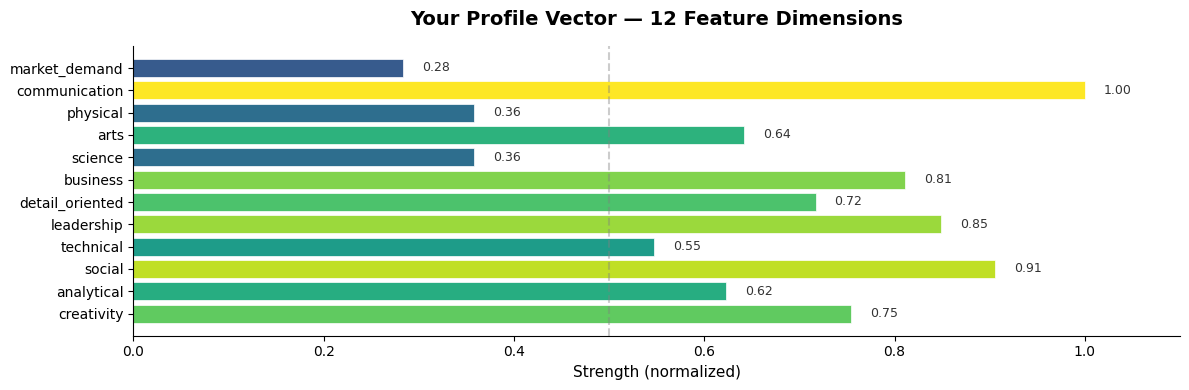


📊 Your raw profile vector:
  creativity         ███████████████░░░░░ 0.755
  analytical         ████████████░░░░░░░░ 0.623
  social             ██████████████████░░ 0.906
  technical          ██████████░░░░░░░░░░ 0.547
  leadership         ████████████████░░░░ 0.849
  detail_oriented    ██████████████░░░░░░ 0.717
  business           ████████████████░░░░ 0.811
  science            ███████░░░░░░░░░░░░░ 0.358
  arts               ████████████░░░░░░░░ 0.642
  physical           ███████░░░░░░░░░░░░░ 0.358
  communication      ████████████████████ 1.000
  market_demand      █████░░░░░░░░░░░░░░░ 0.283


In [9]:
# ── Visualize Your Profile Vector ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.viridis(user_vector)
bars = ax.barh(FEATURE_NAMES, user_vector, color=colors, edgecolor='white', linewidth=0.5)

ax.set_xlim(0, 1.1)
ax.set_xlabel("Strength (normalized)", fontsize=11)
ax.set_title("Your Profile Vector — 12 Feature Dimensions", fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, label='Midpoint')

for bar, val in zip(bars, user_vector):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='#333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('profile_vector.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Your raw profile vector:")
for name, val in zip(FEATURE_NAMES, user_vector):
    bar = '█' * int(val * 20) + '░' * (20 - int(val * 20))
    print(f"  {name:<18} {bar} {val:.3f}")


---
## Section 4 — Stage 1: Cosine Similarity

**What it does:** Measures the *angle* between your profile vector and each career vector.  
A score of 1.0 = perfect alignment. A score of 0.0 = completely opposite.

This gives us our initial ranking of all 20 careers.


In [10]:
# ── Stage 1: Cosine Similarity ───────────────────────────────────────────────
user_vec_2d = user_vector.reshape(1, -1)
cosine_scores = cosine_similarity(user_vec_2d, CAREER_MATRIX)[0]

# Rank all careers
cosine_ranked = sorted(zip(CAREERS, cosine_scores), key=lambda x: x[1], reverse=True)

print("Stage 1 — Cosine Similarity Rankings:")
print(f"{'Rank':<6} {'Career':<28} {'Cosine Score':<15} {'Bar'}")
print("─" * 70)
for rank, (career, score) in enumerate(cosine_ranked, 1):
    bar = '█' * int(score * 30)
    marker = " ◄ TOP 10" if rank <= 10 else ""
    print(f"  {rank:<4} {career:<28} {score:.4f}         {bar}{marker}")

# Keep top 10 for next stages
top10_careers = [c for c, _ in cosine_ranked[:10]]
top10_scores  = {c: s for c, s in cosine_ranked[:10]}
print(f"\n✅ Top 10 shortlisted for Stage 2 & 3: {top10_careers}")


Stage 1 — Cosine Similarity Rankings:
Rank   Career                       Cosine Score    Bar
──────────────────────────────────────────────────────────────────────
  1    Marketing Manager            0.9655         ████████████████████████████ ◄ TOP 10
  2    Journalist                   0.9633         ████████████████████████████ ◄ TOP 10
  3    Content Creator              0.9567         ████████████████████████████ ◄ TOP 10
  4    Entrepreneur                 0.9567         ████████████████████████████ ◄ TOP 10
  5    Teacher                      0.9518         ████████████████████████████ ◄ TOP 10
  6    Product Manager              0.9507         ████████████████████████████ ◄ TOP 10
  7    Lawyer                       0.9379         ████████████████████████████ ◄ TOP 10
  8    Architect                    0.9259         ███████████████████████████ ◄ TOP 10
  9    UX Designer                  0.9193         ███████████████████████████ ◄ TOP 10
  10   Psychologist                 

---
## Section 5 — Stage 2: K-Means Clustering

**What it does:** Groups all 20 careers into clusters of similar profiles.  
Your user vector is then assigned to the nearest cluster.  
Careers in your cluster get a **+boost** added to their final score — because these are careers that "people like you" gravitate toward.


In [11]:
# ── Stage 2: K-Means Clustering ──────────────────────────────────────────────
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
career_labels = kmeans.fit_predict(CAREER_MATRIX)

# Assign user to nearest cluster
user_cluster = kmeans.predict(user_vector.reshape(1, -1))[0]

# Map careers to clusters
cluster_map = {}
for career, label in zip(CAREERS, career_labels):
    cluster_map.setdefault(label, []).append(career)

print(f"K-Means: {N_CLUSTERS} clusters identified\n")
for cid, members in cluster_map.items():
    marker = "  ◄ YOUR CLUSTER" if cid == user_cluster else ""
    print(f"  Cluster {cid}{marker}:")
    for m in members:
        print(f"    • {m}")
    print()

user_cluster_careers = cluster_map[user_cluster]
CLUSTER_BOOST = 0.15
print(f"\n✅ You belong to Cluster {user_cluster}")
print(f"   Careers in your cluster get a +{CLUSTER_BOOST} boost:")
for c in user_cluster_careers:
    print(f"   • {c}")


K-Means: 5 clusters identified

  Cluster 4:
    • Software Engineer
    • Data Scientist
    • Cybersecurity Analyst
    • Financial Analyst

  Cluster 3:
    • UX Designer
    • Architect
    • Graphic Designer
    • Content Creator

  Cluster 0  ◄ YOUR CLUSTER:
    • Product Manager
    • Entrepreneur
    • Lawyer
    • Marketing Manager

  Cluster 1:
    • Doctor
    • Biomedical Engineer
    • Civil Engineer
    • Mechanical Engineer
    • Researcher

  Cluster 2:
    • Psychologist
    • Teacher
    • Journalist


✅ You belong to Cluster 0
   Careers in your cluster get a +0.15 boost:
   • Product Manager
   • Entrepreneur
   • Lawyer
   • Marketing Manager


---
## Section 6 — Stage 3: Weighted Scoring & Final Ranking

**What it does:** Applies dimension weights to compute a final composite score.  
`market_demand` and `technical` get higher weights because they reflect real-world career viability.

Final score formula:
```
final_score = (cosine_score × 0.5) + (cluster_boost × 0.2) + (weighted_dot_product × 0.3)
```


In [12]:
# ── Stage 3: Weighted Scoring ─────────────────────────────────────────────────
# Dimension weights — market_demand and technical weighted higher
DIMENSION_WEIGHTS = np.array([
    0.8,   # creativity
    0.9,   # analytical
    0.8,   # social
    1.0,   # technical
    0.85,  # leadership
    0.85,  # detail_oriented
    0.9,   # business
    0.9,   # science
    0.75,  # arts
    0.7,   # physical
    0.8,   # communication
    1.0,   # market_demand
])
DIMENSION_WEIGHTS = DIMENSION_WEIGHTS / DIMENSION_WEIGHTS.sum()  # normalize

# Weighted user vector
weighted_user = user_vector * DIMENSION_WEIGHTS

# Compute final scores for all careers
final_scores = {}
for i, career in enumerate(CAREERS):
    career_vec = CAREER_MATRIX[i]
    weighted_career = career_vec * DIMENSION_WEIGHTS

    # Component 1: Cosine similarity (50%)
    cos_score = cosine_scores[i]

    # Component 2: Cluster boost (20%)
    cluster_score = CLUSTER_BOOST if career in user_cluster_careers else 0.0

    # Component 3: Weighted dot product (30%)
    dot_score = float(np.dot(weighted_user, weighted_career))
    dot_score = min(dot_score, 1.0)  # cap at 1.0

    # Combined
    final = (cos_score * 0.5) + (cluster_score * 0.2) + (dot_score * 0.3)
    final_scores[career] = {
        "final":   final,
        "cosine":  cos_score,
        "cluster": cluster_score,
        "dot":     dot_score,
    }

# Normalize final scores to percentage (0-100)
raw_scores = np.array([v['final'] for v in final_scores.values()])
scaler = MinMaxScaler(feature_range=(40, 99))
normalized = scaler.fit_transform(raw_scores.reshape(-1, 1)).flatten()

for career, norm_score in zip(CAREERS, normalized):
    final_scores[career]['percent'] = round(float(norm_score), 1)

# Rank
ranked = sorted(final_scores.items(), key=lambda x: x[1]['percent'], reverse=True)

print("Final Composite Scores — All 20 Careers:")
print(f"{'Rank':<5} {'Career':<28} {'% Fit':<8} {'Cosine':<10} {'Cluster':<10} {'Weighted'}")
print("─" * 75)
for rank, (career, scores) in enumerate(ranked, 1):
    marker = " ⭐" if rank <= 5 else ""
    print(f"  {rank:<3} {career:<28} {scores['percent']:>5.1f}%   "
          f"{scores['cosine']:.3f}     {scores['cluster']:.3f}      {scores['dot']:.3f}{marker}")

top5 = ranked[:5]
print(f"\n✅ Top 5 career matches identified.")


Final Composite Scores — All 20 Careers:
Rank  Career                       % Fit    Cosine     Cluster    Weighted
───────────────────────────────────────────────────────────────────────────
  1   Marketing Manager             99.0%   0.966     0.150      0.036 ⭐
  2   Entrepreneur                  97.4%   0.957     0.150      0.040 ⭐
  3   Product Manager               95.8%   0.951     0.150      0.038 ⭐
  4   Lawyer                        92.3%   0.938     0.150      0.035 ⭐
  5   Journalist                    84.0%   0.963     0.000      0.033 ⭐
  6   Content Creator               82.7%   0.957     0.000      0.035
  7   Teacher                       81.2%   0.952     0.000      0.032
  8   Architect                     75.6%   0.926     0.000      0.035
  9   UX Designer                   73.8%   0.919     0.000      0.034
  10  Psychologist                  73.3%   0.917     0.000      0.033
  11  Graphic Designer              64.5%   0.882     0.000      0.030
  12  Doctor     

---
## Section 7 — 🎯 Your Career Match Results

Your personalized Top 5 career recommendations based on the full ML pipeline.


In [13]:
# ── Results Display ───────────────────────────────────────────────────────────
print("\n" + "╔" + "═"*58 + "╗")
print("║" + "  🎯  YOUR TOP 5 CAREER MATCHES".center(58) + "║")
print("╚" + "═"*58 + "╝\n")

medals = ["🥇", "🥈", "🥉", "4️⃣ ", "5️⃣ "]
CAREER_INSIGHTS = {
    "Software Engineer":     "Your analytical + technical profile is a natural fit. High global demand.",
    "Data Scientist":        "Your love of analysis and science makes this a strong match.",
    "UX Designer":           "Your creativity + social awareness aligns well here.",
    "Product Manager":       "Your leadership + business sense suits PM roles perfectly.",
    "Cybersecurity Analyst": "Your technical depth + detail orientation is ideal for this field.",
    "Doctor":                "Your science + social strength maps to medicine. Demanding but rewarding.",
    "Biomedical Engineer":   "Combines your technical and science dimensions uniquely.",
    "Architect":             "Your creativity + technical + detail dimensions align here.",
    "Civil Engineer":        "Your analytical + technical strengths suit this well.",
    "Mechanical Engineer":   "Strong technical + science match. Solid market demand.",
    "Financial Analyst":     "Your analytical + business dimensions drive this match.",
    "Entrepreneur":          "High leadership + business + creativity = entrepreneurial profile.",
    "Lawyer":                "Your communication + analytical + detail dimensions fit law.",
    "Psychologist":          "Your social + communication scores point here.",
    "Teacher":               "Your communication + social strengths make you a natural educator.",
    "Researcher":            "Your analytical + science + detail dimensions are research-grade.",
    "Graphic Designer":      "Your creativity + arts dimensions are dominant here.",
    "Marketing Manager":     "Your communication + business + creativity dimensions align.",
    "Journalist":            "Your communication + arts + social scores drive this match.",
    "Content Creator":       "Your creativity + communication + arts profile fits well.",
}

for i, (career, scores) in enumerate(top5):
    pct = scores['percent']
    bar_filled = int(pct / 5)
    bar = '█' * bar_filled + '░' * (20 - bar_filled)
    insight = CAREER_INSIGHTS.get(career, "Strong alignment across multiple dimensions.")

    print(f"  {medals[i]}  {career}")
    print(f"      Fit Score:  [{bar}] {pct:.1f}%")
    print(f"      Why:        {insight}")
    print(f"      Breakdown:  Similarity={scores['cosine']:.2f} | "
          f"Cluster={'Yes' if scores['cluster']>0 else 'No'} | "
          f"Weighted={scores['dot']:.2f}")
    print()

print("─" * 60)
print("  💡 Tip: Your top match isn't your only option.")
print("     Explore #2 and #3 — they often reveal hidden strengths.")
print("─" * 60)



╔══════════════════════════════════════════════════════════╗
║                🎯  YOUR TOP 5 CAREER MATCHES              ║
╚══════════════════════════════════════════════════════════╝

  🥇  Marketing Manager
      Fit Score:  [███████████████████░] 99.0%
      Why:        Your communication + business + creativity dimensions align.
      Breakdown:  Similarity=0.97 | Cluster=Yes | Weighted=0.04

  🥈  Entrepreneur
      Fit Score:  [███████████████████░] 97.4%
      Why:        High leadership + business + creativity = entrepreneurial profile.
      Breakdown:  Similarity=0.96 | Cluster=Yes | Weighted=0.04

  🥉  Product Manager
      Fit Score:  [███████████████████░] 95.8%
      Why:        Your leadership + business sense suits PM roles perfectly.
      Breakdown:  Similarity=0.95 | Cluster=Yes | Weighted=0.04

  4️⃣   Lawyer
      Fit Score:  [██████████████████░░] 92.3%
      Why:        Your communication + analytical + detail dimensions fit law.
      Breakdown:  Similarity=0.94 |

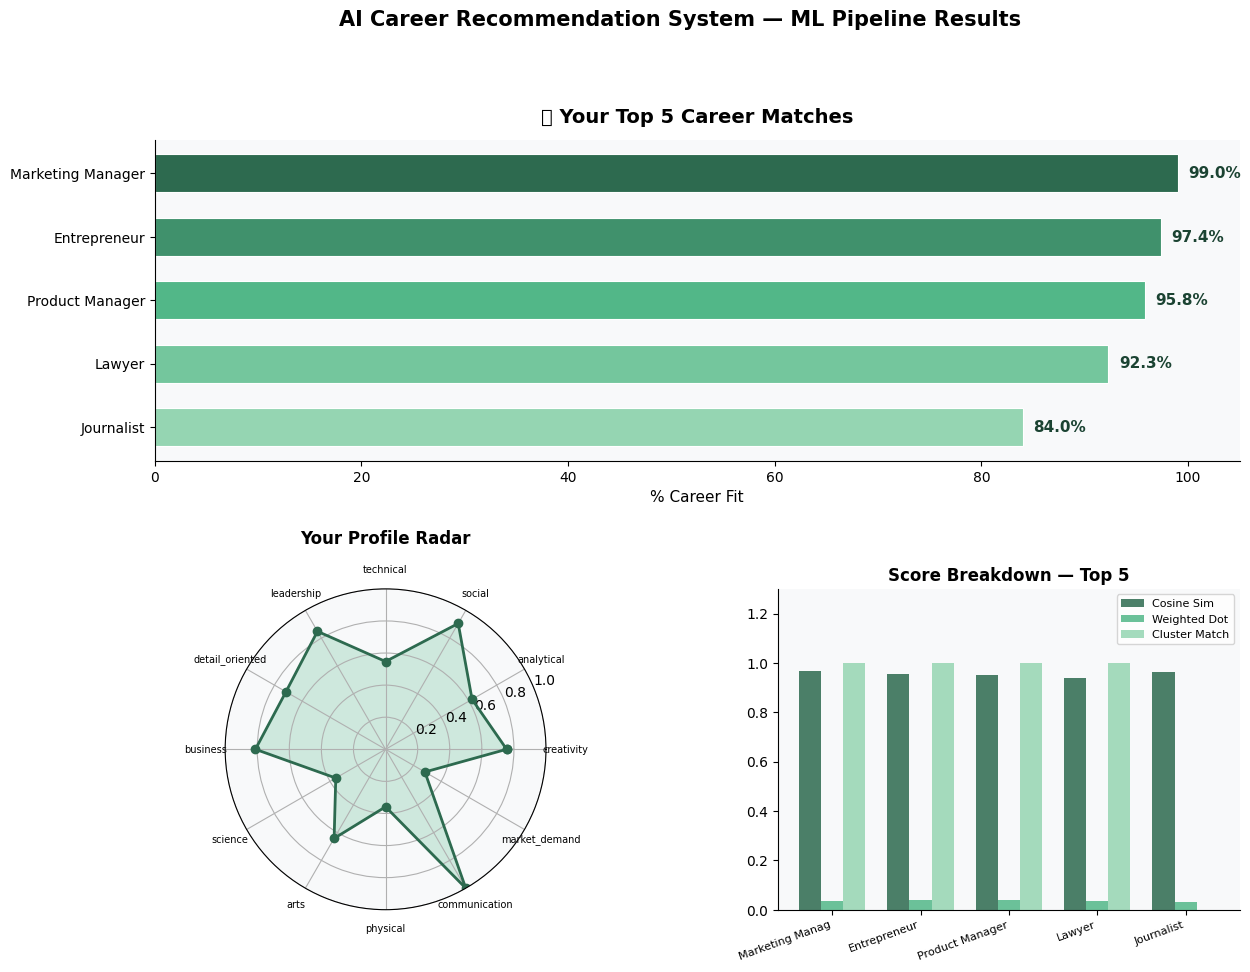

✅ Visualization saved to career_results.png


In [14]:
# ── Final Visualization ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Top 5 Bar Chart ──
ax1 = fig.add_subplot(gs[0, :])
careers_plot = [c for c, _ in top5]
scores_plot  = [s['percent'] for _, s in top5]
palette = ['#2D6A4F', '#40916C', '#52B788', '#74C69D', '#95D5B2']
bars = ax1.barh(careers_plot[::-1], scores_plot[::-1], color=palette[::-1],
                edgecolor='white', linewidth=0.8, height=0.6)
ax1.set_xlim(0, 105)
ax1.set_xlabel("% Career Fit", fontsize=11)
ax1.set_title("🎯 Your Top 5 Career Matches", fontsize=14, fontweight='bold', pad=12)
for bar, score in zip(bars, scores_plot[::-1]):
    ax1.text(score + 1, bar.get_y() + bar.get_height()/2,
             f'{score:.1f}%', va='center', fontsize=11, fontweight='bold', color='#1B4332')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('#F8F9FA')

# ── Plot 2: Your Profile Radar ──
ax2 = fig.add_subplot(gs[1, 0], projection='polar')
angles = np.linspace(0, 2*np.pi, len(FEATURE_NAMES), endpoint=False).tolist()
values = user_vector.tolist()
angles += angles[:1]; values += values[:1]
ax2.plot(angles, values, 'o-', linewidth=2, color='#2D6A4F')
ax2.fill(angles, values, alpha=0.25, color='#52B788')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(FEATURE_NAMES, size=7)
ax2.set_ylim(0, 1)
ax2.set_title("Your Profile Radar", size=12, fontweight='bold', pad=15)
ax2.set_facecolor('#F8F9FA')

# ── Plot 3: Score Component Breakdown ──
ax3 = fig.add_subplot(gs[1, 1])
top5_labels = [c[:15] for c, _ in top5]
cos_vals  = [s['cosine'] for _, s in top5]
dot_vals  = [s['dot']    for _, s in top5]
cl_vals   = [1 if s['cluster'] > 0 else 0 for _, s in top5]
x = np.arange(len(top5_labels))
w = 0.25
ax3.bar(x - w, cos_vals, w, label='Cosine Sim',    color='#2D6A4F', alpha=0.85)
ax3.bar(x,     dot_vals, w, label='Weighted Dot',  color='#52B788', alpha=0.85)
ax3.bar(x + w, cl_vals,  w, label='Cluster Match', color='#95D5B2', alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(top5_labels, rotation=20, ha='right', fontsize=8)
ax3.set_ylim(0, 1.3)
ax3.set_title("Score Breakdown — Top 5", fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_facecolor('#F8F9FA')

fig.suptitle("AI Career Recommendation System — ML Pipeline Results",
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('career_results.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Visualization saved to career_results.png")


---
## ✅ Pipeline Complete

| Stage | Method | Purpose |
|-------|--------|---------|
| 1 | **Cosine Similarity** | Raw profile-to-career distance |
| 2 | **K-Means Clustering** | Peer-group career boost |
| 3 | **Weighted Dot Product** | Market-demand aware scoring |

**Next steps you could build:**
- 🗺️ Learning roadmap generator per career
- 📁 Project ideas recommender
- 🌍 MENA market demand data integration
- 💾 Save/load user profiles as JSON
- 🖥️ Wrap in a Streamlit web app
